In [ ]:
# ==========================================
# 1. LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt




In [ ]:
# ==========================================
# 2. LOAD DATA
# ==========================================
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(X.head())
print(y.value_counts())



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
species
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)



In [ ]:
# ==========================================
# 4. SCALING (for KNN)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# ==========================================
# 5. MODELS
# ==========================================
models = {
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "CART": DecisionTreeClassifier(max_depth=4, random_state=42)
}

results = []

for name, model in models.items():
    # For KNN use scaled data
    if "KNN" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))




=== Naive Bayes ===
Accuracy: 0.911
Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


=== KNN (k=5) ===
Accuracy: 0.911
Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45


=== CART ===
Accuracy: 0.889
Confusion Matrix:
 [[15 

In [ ]:
# ==========================================
# 6. COMPARISON TABLE
# ==========================================
df_results = pd.DataFrame(results)
print("\nModel Comparison:\n", df_results)




Model Comparison:
          Model  Accuracy
0  Naive Bayes  0.911111
1    KNN (k=5)  0.911111
2         CART  0.888889


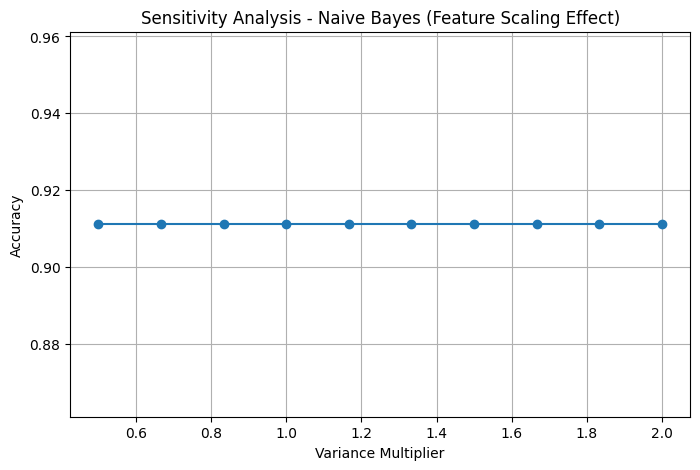

In [ ]:
# ==========================================
# 7. SENSITIVITY ANALYSIS - NAIVE BAYES
# ==========================================
# We'll simulate different feature scales (variance) to see impact on performance
variances = np.linspace(0.5, 2.0, 10)
accuracies = []

for v in variances:
    X_train_var = X_train * v
    X_test_var = X_test * v
    nb = GaussianNB()
    nb.fit(X_train_var, y_train)
    y_pred = nb.predict(X_test_var)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(variances, accuracies, marker='o')
plt.title("Sensitivity Analysis - Naive Bayes (Feature Scaling Effect)")
plt.xlabel("Variance Multiplier")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()



In [ ]:
# ==========================================
# 8. CROSS VALIDATION (to estimate stability)
# ==========================================
for name, model in models.items():
    if "KNN" in name:
        scores = cross_val_score(model, X, y, cv=5)
    else:
        scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Mean Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

Naive Bayes CV Mean Accuracy: 0.953 (+/- 0.027)
KNN (k=5) CV Mean Accuracy: 0.973 (+/- 0.025)
CART CV Mean Accuracy: 0.953 (+/- 0.034)
